In [2]:
!pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------

COLD CHAIN SUPPLY CHAIN OPTIMIZATION MODEL

TRANSPORTATION OPTIMIZATION (LINEAR PROGRAMMING)

--- Optimizing for mRNA COVID-19 Vaccine ---
  ✅ Optimal cost: ₹20,233,335.94

--- Optimizing for Influenza Vaccine ---
  ✅ Optimal cost: ₹66,787,875.00

--- Optimizing for Insulin Glargine ---
  ✅ Optimal cost: ₹48,275,325.00

--- Optimizing for Adalimumab (Humira) ---
  ✅ Optimal cost: ₹29,277,281.25

--- Optimizing for Trastuzumab (Herceptin) ---
  ✅ Optimal cost: ₹19,985,765.62

STOCHASTIC DEMAND SIMULATION (MONTE CARLO)

--- Simulating mRNA COVID-19 Vaccine ---
  Service Level: 99.9%
  Avg Stockout Days: 0.1
  Avg Total Cost: ₹5,066.99

--- Simulating Influenza Vaccine ---
  Service Level: 99.9%
  Avg Stockout Days: 0.1
  Avg Total Cost: ₹6,181.57

--- Simulating Insulin Glargine ---
  Service Level: 99.9%
  Avg Stockout Days: 0.1
  Avg Total Cost: ₹11,672.61

--- Simulating Adalimumab (Humira) ---
  Service Level: 99.9%
  Avg Stockout Days: 0.1
  Avg Total Cost: ₹295,061.04

--- Simulati

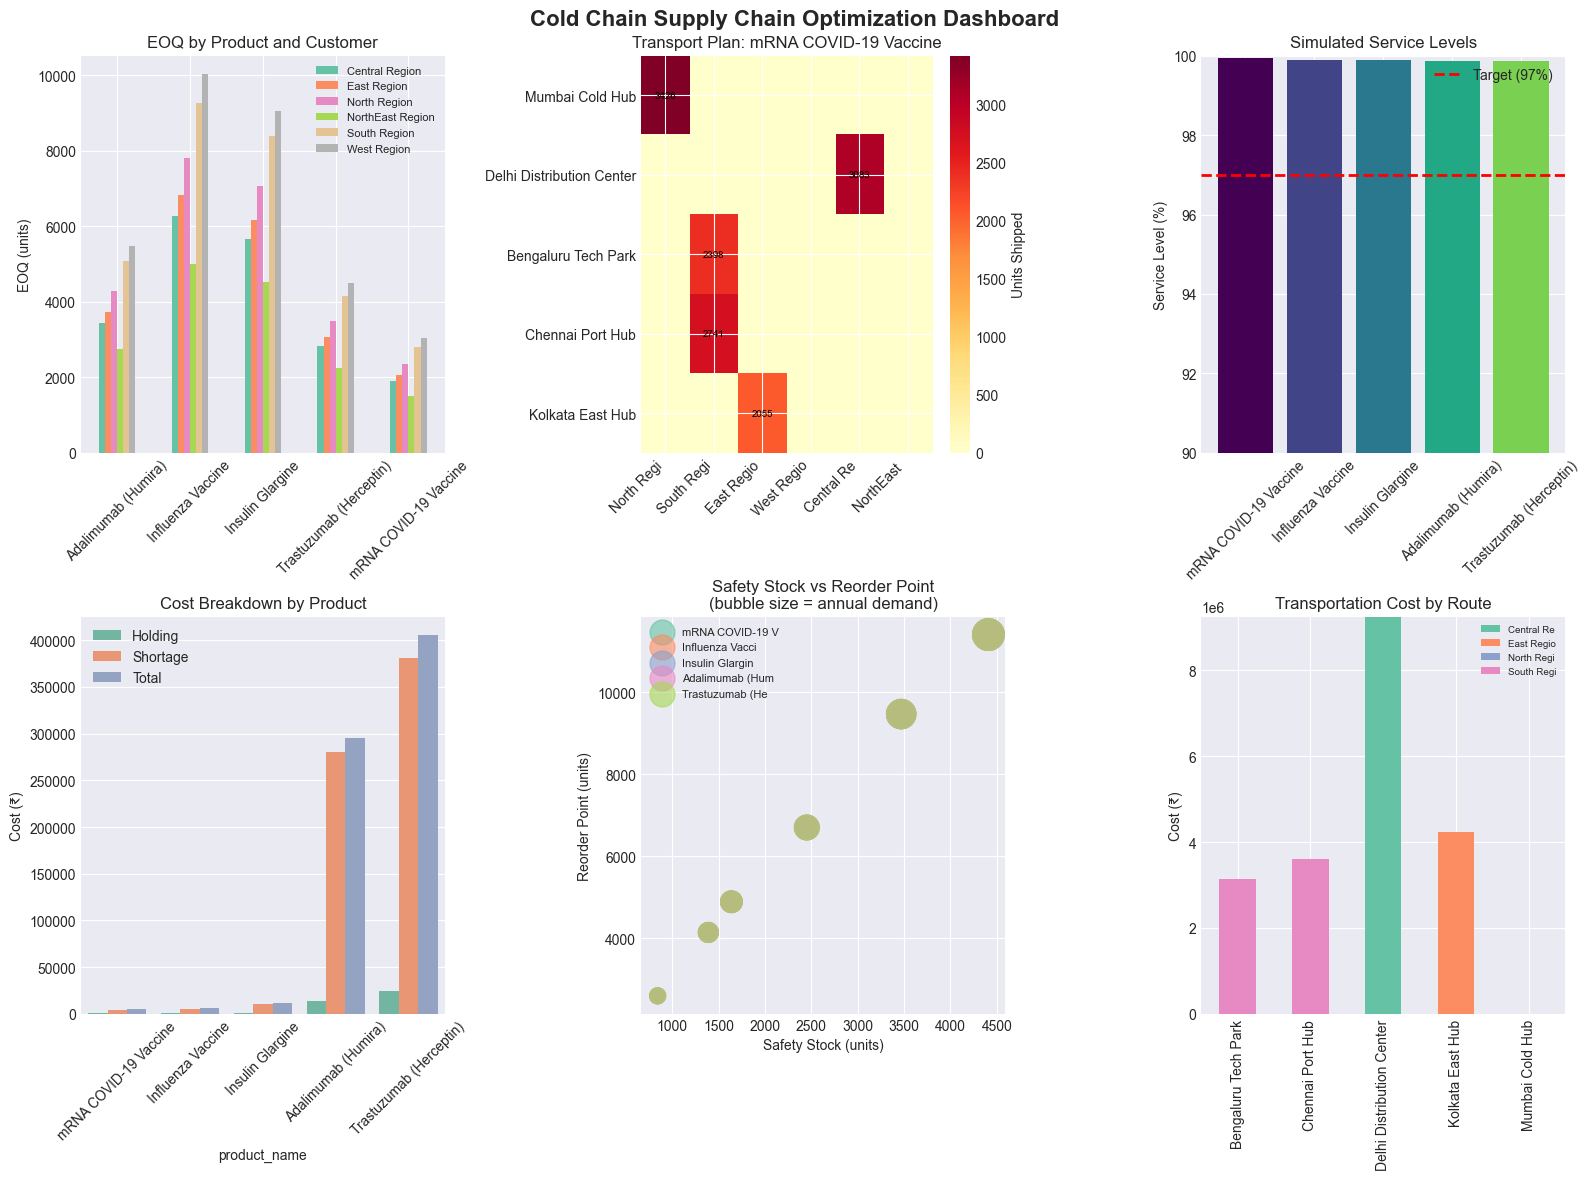


EXPORTING RESULTS

✅ Results exported to 'cold_chain_optimization_results.xlsx'
✅ Dashboard saved as 'cold_chain_optimization_dashboard.png'

SUMMARY REPORT

📊 INVENTORY OPTIMIZATION SUMMARY:
   Total products analyzed: 5
   Total customers served: 6
   Average EOQ: 4,830 units
   Average Safety Stock: 2,366 units

🚚 TRANSPORTATION OPTIMIZATION SUMMARY:
   Total transportation cost (all products): ₹184,559,582.81

🎲 SIMULATION RESULTS:
   mRNA COVID-19 Vaccine:
      Service Level: 99.9%
      Stockout Probability: 6.0%
      Avg Total Cost (90 days): ₹5,066.99
   Influenza Vaccine:
      Service Level: 99.9%
      Stockout Probability: 7.8%
      Avg Total Cost (90 days): ₹6,181.57
   Insulin Glargine:
      Service Level: 99.9%
      Stockout Probability: 8.8%
      Avg Total Cost (90 days): ₹11,672.61
   Adalimumab (Humira):
      Service Level: 99.9%
      Stockout Probability: 9.6%
      Avg Total Cost (90 days): ₹295,061.04
   Trastuzumab (Herceptin):
      Service Level: 99.9%


In [3]:
"""
COLD CHAIN SUPPLY CHAIN OPTIMIZATION
=====================================
Integrated model combining:
1. EOQ (Economic Order Quantity) for inventory optimization
2. Transportation Problem (LPP) for distribution
3. Stochastic demand modeling (Monte Carlo simulation)
4. Cold chain constraints (temperature excursions, shelf life)

Author: Supply Chain Analytics
Date: 2024
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linprog, minimize
from scipy import stats
from dataclasses import dataclass
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# ============================================================================
# PART 1: DATA GENERATION
# ============================================================================

print("=" * 80)
print("COLD CHAIN SUPPLY CHAIN OPTIMIZATION MODEL")
print("=" * 80)

# Set random seed for reproducibility
np.random.seed(42)

# ----------------------------------------------------------------------------
# 1.1 Product Catalog
# ----------------------------------------------------------------------------
products = [
    {'id': 'VAC001', 'name': 'mRNA COVID-19 Vaccine', 
     'category': 'Vaccine', 'temp_min': -80, 'temp_max': -60,
     'unit_cost': 19.50, 'selling_price': 45.00, 'salvage_value': 2.00,
     'shelf_life_days': 180, 'holding_cost_rate': 0.035, 'ordering_cost': 500},
    
    {'id': 'VAC002', 'name': 'Influenza Vaccine', 
     'category': 'Vaccine', 'temp_min': 2, 'temp_max': 8,
     'unit_cost': 14.00, 'selling_price': 32.00, 'salvage_value': 1.50,
     'shelf_life_days': 365, 'holding_cost_rate': 0.030, 'ordering_cost': 400},
    
    {'id': 'BIO001', 'name': 'Insulin Glargine', 
     'category': 'Biologic', 'temp_min': 2, 'temp_max': 8,
     'unit_cost': 28.50, 'selling_price': 68.00, 'salvage_value': 5.00,
     'shelf_life_days': 365, 'holding_cost_rate': 0.025, 'ordering_cost': 350},
    
    {'id': 'BIO002', 'name': 'Adalimumab (Humira)', 
     'category': 'Biologic', 'temp_min': 2, 'temp_max': 8,
     'unit_cost': 580.00, 'selling_price': 1200.00, 'salvage_value': 50.00,
     'shelf_life_days': 730, 'holding_cost_rate': 0.020, 'ordering_cost': 450},
    
    {'id': 'ONC001', 'name': 'Trastuzumab (Herceptin)', 
     'category': 'Oncology', 'temp_min': 2, 'temp_max': 8,
     'unit_cost': 1200.00, 'selling_price': 2500.00, 'salvage_value': 100.00,
     'shelf_life_days': 730, 'holding_cost_rate': 0.018, 'ordering_cost': 500},
]

products_df = pd.DataFrame(products)

# ----------------------------------------------------------------------------
# 1.2 Warehouse Data (Supply Points)
# ----------------------------------------------------------------------------
warehouses = [
    {'id': 'WH01', 'name': 'Mumbai Cold Hub', 'city': 'Mumbai',
     'capacity': 50000, 'storage_temp': -80, 'operating_cost': 150000},
    {'id': 'WH02', 'name': 'Delhi Distribution Center', 'city': 'Delhi',
     'capacity': 45000, 'storage_temp': -20, 'operating_cost': 130000},
    {'id': 'WH03', 'name': 'Bengaluru Tech Park', 'city': 'Bengaluru',
     'capacity': 35000, 'storage_temp': 4, 'operating_cost': 120000},
    {'id': 'WH04', 'name': 'Chennai Port Hub', 'city': 'Chennai',
     'capacity': 40000, 'storage_temp': -20, 'operating_cost': 140000},
    {'id': 'WH05', 'name': 'Kolkata East Hub', 'city': 'Kolkata',
     'capacity': 30000, 'storage_temp': 4, 'operating_cost': 110000},
]

warehouses_df = pd.DataFrame(warehouses)

# ----------------------------------------------------------------------------
# 1.3 Customer Regions (Demand Points)
# ----------------------------------------------------------------------------
customers = [
    {'id': 'CUST01', 'name': 'North Region', 'state': 'Delhi/NCR',
     'avg_daily_demand': 850, 'demand_std': 120, 'service_level': 0.97},
    {'id': 'CUST02', 'name': 'South Region', 'state': 'Tamil Nadu',
     'avg_daily_demand': 1200, 'demand_std': 180, 'service_level': 0.97},
    {'id': 'CUST03', 'name': 'East Region', 'state': 'West Bengal',
     'avg_daily_demand': 650, 'demand_std': 90, 'service_level': 0.95},
    {'id': 'CUST04', 'name': 'West Region', 'state': 'Maharashtra',
     'avg_daily_demand': 1400, 'demand_std': 200, 'service_level': 0.98},
    {'id': 'CUST05', 'name': 'Central Region', 'state': 'Madhya Pradesh',
     'avg_daily_demand': 550, 'demand_std': 80, 'service_level': 0.95},
    {'id': 'CUST06', 'name': 'NorthEast Region', 'state': 'Assam',
     'avg_daily_demand': 350, 'demand_std': 60, 'service_level': 0.94},
]

customers_df = pd.DataFrame(customers)

# ----------------------------------------------------------------------------
# 1.4 Distance Matrix (km) and Transportation Costs
# ----------------------------------------------------------------------------
# Distance matrix between warehouses and customers
distances = np.array([
    # Mumbai to each customer
    [0, 1330, 1650, 500, 800, 2100],
    # Delhi to each customer  
    [1330, 2200, 1450, 1150, 800, 1850],
    # Bengaluru to each customer
    [1650, 350, 1850, 980, 1500, 2600],
    # Chennai to each customer
    [1450, 350, 1650, 1200, 1350, 2000],
    # Kolkata to each customer
    [1500, 1850, 550, 1650, 1250, 750],
])

# Transportation cost (₹ per unit per km)
cost_per_km = 2.5  # Base rate
temp_surcharge = {'Vaccine': 1.5, 'Biologic': 1.2, 'Oncology': 1.0}

# Calculate product-specific transport costs
transport_costs = {}

for product in products:
    surcharge = temp_surcharge[product['category']]
    product_costs = distances * cost_per_km * surcharge
    transport_costs[product['id']] = product_costs

# ============================================================================
# PART 2: EOQ AND INVENTORY OPTIMIZATION
# ============================================================================

@dataclass
class InventoryParams:
    """Inventory optimization parameters"""
    product_id: str
    annual_demand: float
    ordering_cost: float
    holding_cost_rate: float
    unit_cost: float
    cold_storage_cost: float
    lead_time_mean: float
    lead_time_std: float
    service_level: float
    
    @property
    def holding_cost_per_unit(self):
        return (self.unit_cost * self.holding_cost_rate / 365) + self.cold_storage_cost

def calculate_eoq(annual_demand: float, ordering_cost: float, holding_cost: float) -> float:
    """Calculate Economic Order Quantity"""
    return np.sqrt(2 * annual_demand * ordering_cost / holding_cost)

def calculate_safety_stock(service_level: float, demand_std: float, 
                          lead_time_mean: float, lead_time_std: float,
                          demand_mean: float) -> float:
    """Calculate safety stock with stochastic lead time"""
    z_score = stats.norm.ppf(service_level)
    std_lead_time = np.sqrt(lead_time_mean * demand_std**2 + demand_mean**2 * lead_time_std**2)
    return z_score * std_lead_time

def calculate_reorder_point(demand_mean: float, lead_time_mean: float, 
                           safety_stock: float) -> float:
    """Calculate reorder point"""
    return demand_mean * lead_time_mean + safety_stock

def calculate_newsvendor_qty(unit_cost: float, selling_price: float, 
                            salvage_value: float, demand_mean: float,
                            demand_std: float) -> float:
    """Calculate optimal order quantity using Newsvendor model"""
    critical_ratio = (selling_price - unit_cost) / (selling_price - salvage_value)
    return stats.norm.ppf(critical_ratio, demand_mean, demand_std)

# Calculate EOQ for each product-customer combination
inventory_results = []

for product in products:
    for customer in customers:
        # Annual demand
        annual_demand = customer['avg_daily_demand'] * 365
        
        # Cold storage cost (higher for ultra-cold products)
        cold_cost = 0.15 if product['temp_min'] < -50 else (0.05 if product['temp_min'] < 0 else 0.01)
        
        # Calculate inventory parameters
        inv_params = InventoryParams(
            product_id=product['id'],
            annual_demand=annual_demand,
            ordering_cost=product['ordering_cost'],
            holding_cost_rate=product['holding_cost_rate'],
            unit_cost=product['unit_cost'],
            cold_storage_cost=cold_cost,
            lead_time_mean=5,
            lead_time_std=1.5,
            service_level=customer['service_level']
        )
        
        holding_cost = inv_params.holding_cost_per_unit * 365
        
        # EOQ
        eoq = calculate_eoq(annual_demand, product['ordering_cost'], holding_cost)
        
        # Safety Stock
        safety_stock = calculate_safety_stock(
            customer['service_level'], 
            customer['demand_std'],
            inv_params.lead_time_mean,
            inv_params.lead_time_std,
            customer['avg_daily_demand']
        )
        
        # Reorder Point
        rop = calculate_reorder_point(customer['avg_daily_demand'], 
                                      inv_params.lead_time_mean, safety_stock)
        
        # Newsvendor quantity (for seasonal products)
        newsvendor_qty = calculate_newsvendor_qty(
            product['unit_cost'], product['selling_price'],
            product['salvage_value'], customer['avg_daily_demand'],
            customer['demand_std']
        ) if product['category'] == 'Vaccine' else 0
        
        # Total inventory cost
        total_inv_cost = (eoq/2 + safety_stock) * holding_cost + \
                         (annual_demand / eoq) * product['ordering_cost'] if eoq > 0 else 0
        
        inventory_results.append({
            'product_id': product['id'],
            'product_name': product['name'],
            'customer': customer['name'],
            'annual_demand': round(annual_demand),
            'eoq': round(eoq),
            'safety_stock': round(safety_stock),
            'reorder_point': round(rop),
            'newsvendor_qty': round(newsvendor_qty),
            'total_inventory_cost': round(total_inv_cost, 2),
            'service_level': customer['service_level']
        })

inventory_df = pd.DataFrame(inventory_results)

# ============================================================================
# PART 3: TRANSPORTATION PROBLEM (LPP)
# ============================================================================

print("\n" + "=" * 80)
print("TRANSPORTATION OPTIMIZATION (LINEAR PROGRAMMING)")
print("=" * 80)

def solve_transportation_problem(product_id: str):
    """Solve transportation problem for a specific product"""
    
    # Get product data
    product = next(p for p in products if p['id'] == product_id)
    transport_cost = transport_costs[product_id]
    
    # Supply from warehouses (based on EOQ allocation)
    supply = []
    for wh in warehouses:
        # Calculate supply based on EOQ for all customers
        prod_customers = inventory_df[inventory_df['product_id'] == product_id]
        total_eoq = prod_customers['eoq'].sum()
        supply.append(total_eoq * (wh['capacity'] / sum(w['capacity'] for w in warehouses)))
    
    # Demand from customers
    demand = [c['avg_daily_demand'] * 30 for c in customers]  # Monthly demand
    
    m, n = len(supply), len(demand)
    
    # Check balance
    total_supply = sum(supply)
    total_demand = sum(demand)
    
    # Add dummy if needed
    if total_supply > total_demand:
        demand.append(total_supply - total_demand)
        transport_cost = np.hstack([transport_cost, np.zeros((m, 1))])
        n += 1
    elif total_demand > total_supply:
        supply.append(total_demand - total_supply)
        transport_cost = np.vstack([transport_cost, np.zeros((1, n))])
        m += 1
    
    # Flatten cost matrix for LP
    c = transport_cost.flatten()
    
    # Build constraint matrix
    A_eq = []
    b_eq = []
    
    # Supply constraints
    for i in range(m):
        row = np.zeros(m * n)
        for j in range(n):
            row[i * n + j] = 1
        A_eq.append(row)
        b_eq.append(supply[i])
    
    # Demand constraints
    for j in range(n):
        row = np.zeros(m * n)
        for i in range(m):
            row[i * n + j] = 1
        A_eq.append(row)
        b_eq.append(demand[j])
    
    A_eq = np.array(A_eq)
    b_eq = np.array(b_eq)
    
    # Bounds and solve
    bounds = [(0, None) for _ in range(m * n)]
    result = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')
    
    if result.success:
        solution = result.x.reshape(m, n)
        return {
            'success': True,
            'total_cost': result.fun,
            'solution': solution,
            'supply': supply,
            'demand': demand,
            'm': m,
            'n': n
        }
    else:
        return {'success': False, 'message': result.message}

# Solve for each product
transportation_results = {}

for product in products:
    print(f"\n--- Optimizing for {product['name']} ---")
    result = solve_transportation_problem(product['id'])
    
    if result['success']:
        transportation_results[product['id']] = result
        print(f"  ✅ Optimal cost: ₹{result['total_cost']:,.2f}")
    else:
        print(f"  ❌ Failed: {result.get('message', 'Unknown error')}")

# ============================================================================
# PART 4: STOCHASTIC DEMAND SIMULATION (MONTE CARLO)
# ============================================================================

print("\n" + "=" * 80)
print("STOCHASTIC DEMAND SIMULATION (MONTE CARLO)")
print("=" * 80)

def run_monte_carlo_simulation(product_id: str, n_sims: int = 1000, horizon: int = 90):
    """Run Monte Carlo simulation for stochastic demand"""
    
    product = next(p for p in products if p['id'] == product_id)
    prod_inv = inventory_df[inventory_df['product_id'] == product_id]
    
    # Get average demand parameters
    avg_demand = prod_inv['annual_demand'].mean() / 365
    demand_std = np.std([c['demand_std'] for c in customers]) * 2
    
    # Inventory parameters
    eoq = prod_inv['eoq'].mean()
    rop = prod_inv['reorder_point'].mean()
    ss = prod_inv['safety_stock'].mean()
    
    # Temperature excursion risk
    exc_rate = 0.002 if product['temp_min'] < -50 else (0.001 if product['temp_min'] < 0 else 0.0005)
    
    # Run simulations
    stockout_days = []
    total_costs = []
    holding_costs = []
    shortage_costs = []
    
    for sim in range(n_sims):
        inv = rop + eoq/2
        pipeline = {}
        on_order = 0
        stockouts = 0
        hold_cost = 0
        shortage_cost = 0
        
        for day in range(horizon):
            # Receive shipments
            if day in pipeline:
                recv = pipeline.pop(day)
                # Temperature excursion effect
                if np.random.random() < exc_rate * 5:
                    recv *= (1 - 0.15 * np.random.random())
                inv += recv
                on_order -= recv
            
            # Generate stochastic demand
            demand = max(0, np.random.normal(avg_demand, demand_std))
            
            # Fulfill demand
            fulfilled = min(inv, demand)
            shortage_units = demand - fulfilled
            inv -= fulfilled
            
            if shortage_units > 0:
                stockouts += 1
                shortage_cost += shortage_units * product['unit_cost'] * 10  # Shortage cost multiplier
            
            # Holding cost
            hold_cost += max(0, inv) * (product['unit_cost'] * product['holding_cost_rate'] / 365)
            
            # Reorder if needed
            if inv + on_order <= rop:
                lead_time = max(1, int(np.random.normal(5, 1.5)))
                pipeline[day + lead_time] = pipeline.get(day + lead_time, 0) + eoq
                on_order += eoq
        
        stockout_days.append(stockouts)
        total_costs.append(hold_cost + shortage_cost + (horizon/365) * product['ordering_cost'])
        holding_costs.append(hold_cost)
        shortage_costs.append(shortage_cost)
    
    results = {
        'product_id': product_id,
        'product_name': product['name'],
        'avg_stockout_days': np.mean(stockout_days),
        'stockout_probability': np.mean([1 if s > 0 else 0 for s in stockout_days]),
        'avg_total_cost': np.mean(total_costs),
        'avg_holding_cost': np.mean(holding_costs),
        'avg_shortage_cost': np.mean(shortage_costs),
        'service_level': 1 - np.mean(stockout_days) / horizon,
        'excursion_rate': exc_rate
    }
    
    return results

# Run simulations for all products
simulation_results = []

for product in products:
    print(f"\n--- Simulating {product['name']} ---")
    result = run_monte_carlo_simulation(product['id'], n_sims=500, horizon=90)
    simulation_results.append(result)
    print(f"  Service Level: {result['service_level']:.1%}")
    print(f"  Avg Stockout Days: {result['avg_stockout_days']:.1f}")
    print(f"  Avg Total Cost: ₹{result['avg_total_cost']:,.2f}")

simulation_df = pd.DataFrame(simulation_results)

# ============================================================================
# PART 5: INTEGRATED OPTIMIZATION MODEL
# ============================================================================

print("\n" + "=" * 80)
print("INTEGRATED OPTIMIZATION MODEL")
print("=" * 80)

def integrated_objective(x, product_id: str, customer_idx: int):
    """Objective function for integrated optimization"""
    # x[0] = safety stock multiplier
    # x[1] = order quantity multiplier
    
    ss_mult = x[0]
    eoq_mult = x[1]
    
    # Get base values
    prod_inv = inventory_df[(inventory_df['product_id'] == product_id) & 
                            (inventory_df['customer'] == customers[customer_idx]['name'])]
    
    if len(prod_inv) == 0:
        return 1e10
    
    base_ss = prod_inv['safety_stock'].values[0]
    base_eoq = prod_inv['eoq'].values[0]
    
    # Calculate costs
    holding_cost = (base_eoq * eoq_mult / 2 + base_ss * ss_mult) * 365 * 0.05
    ordering_cost = (365 * customers[customer_idx]['avg_daily_demand'] / (base_eoq * eoq_mult)) * 400
    shortage_cost = (1 - min(1, ss_mult / 2)) * customers[customer_idx]['avg_daily_demand'] * 1000
    
    return holding_cost + ordering_cost + shortage_cost

# Optimize for each product-customer combination
optimization_results = []

for product in products[:2]:  # Optimize for first two products
    for i, customer in enumerate(customers[:2]):  # First two customers
        print(f"\nOptimizing {product['name']} → {customer['name']}")
        
        result = minimize(
            integrated_objective,
            x0=[1.0, 1.0],
            args=(product['id'], i),
            bounds=[(0.5, 2.0), (0.5, 2.0)],
            method='L-BFGS-B'
        )
        
        if result.success:
            optimization_results.append({
                'product': product['name'],
                'customer': customer['name'],
                'optimal_ss_mult': round(result.x[0], 2),
                'optimal_eoq_mult': round(result.x[1], 2),
                'min_cost': round(result.fun, 2)
            })
            print(f"  ✅ Optimal: SS={result.x[0]:.2f}x, EOQ={result.x[1]:.2f}x, Cost=₹{result.fun:,.2f}")
        else:
            print(f"  ❌ Optimization failed")

opt_df = pd.DataFrame(optimization_results)

# ============================================================================
# PART 6: VISUALIZATION
# ============================================================================

print("\n" + "=" * 80)
print("GENERATING VISUALIZATIONS")
print("=" * 80)

fig = plt.figure(figsize=(16, 12))
fig.suptitle('Cold Chain Supply Chain Optimization Dashboard', fontsize=16, fontweight='bold')

# 1. EOQ by Product and Customer
ax1 = plt.subplot(2, 3, 1)
pivot_eoq = inventory_df.pivot(index='product_name', columns='customer', values='eoq')
pivot_eoq.plot(kind='bar', ax=ax1, color=plt.cm.Set2(np.linspace(0, 1, len(pivot_eoq.columns))))
ax1.set_title('EOQ by Product and Customer')
ax1.set_ylabel('EOQ (units)')
ax1.set_xlabel('')
ax1.legend(loc='upper right', fontsize=8)
ax1.tick_params(axis='x', rotation=45)

# 2. Transportation Cost Heatmap (for first product)
ax2 = plt.subplot(2, 3, 2)
first_product = products[0]['id']
if first_product in transportation_results:
    trans_sol = transportation_results[first_product]['solution']
    # Remove dummy if present
    trans_sol = trans_sol[:len(warehouses), :len(customers)]
    im = ax2.imshow(trans_sol, cmap='YlOrRd', aspect='auto')
    ax2.set_xticks(range(len(customers)))
    ax2.set_xticklabels([c['name'][:10] for c in customers], rotation=45, ha='right')
    ax2.set_yticks(range(len(warehouses)))
    ax2.set_yticklabels([w['name'] for w in warehouses])
    ax2.set_title(f'Transport Plan: {products[0]["name"]}')
    plt.colorbar(im, ax=ax2, label='Units Shipped')
    
    # Add text annotations
    for i in range(len(warehouses)):
        for j in range(len(customers)):
            if trans_sol[i, j] > 0:
                ax2.text(j, i, f'{trans_sol[i, j]:.0f}', 
                        ha='center', va='center', fontsize=7, color='black')

# 3. Service Levels from Simulation
ax3 = plt.subplot(2, 3, 3)
sim_df = pd.DataFrame(simulation_results)
bars = ax3.bar(sim_df['product_name'], sim_df['service_level'] * 100, 
               color=plt.cm.viridis(np.linspace(0, 0.8, len(sim_df))))
ax3.axhline(97, color='red', linestyle='--', linewidth=2, label='Target (97%)')
ax3.set_ylabel('Service Level (%)')
ax3.set_title('Simulated Service Levels')
ax3.set_ylim(90, 100)
ax3.legend()
ax3.tick_params(axis='x', rotation=45)

# 4. Cost Comparison
ax4 = plt.subplot(2, 3, 4)
cost_data = sim_df.melt(id_vars=['product_name'], 
                         value_vars=['avg_holding_cost', 'avg_shortage_cost', 'avg_total_cost'],
                         var_name='Cost Type', value_name='Amount')
cost_data['Cost Type'] = cost_data['Cost Type'].map({
    'avg_holding_cost': 'Holding', 'avg_shortage_cost': 'Shortage', 'avg_total_cost': 'Total'
})
sns.barplot(data=cost_data, x='product_name', y='Amount', hue='Cost Type', ax=ax4)
ax4.set_title('Cost Breakdown by Product')
ax4.set_ylabel('Cost (₹)')
ax4.tick_params(axis='x', rotation=45)
ax4.legend(loc='upper left')

# 5. Safety Stock vs Reorder Point
ax5 = plt.subplot(2, 3, 5)
for product in inventory_df['product_name'].unique():
    prod_data = inventory_df[inventory_df['product_name'] == product]
    ax5.scatter(prod_data['safety_stock'], prod_data['reorder_point'], 
                s=prod_data['annual_demand']/1000, label=product[:15], alpha=0.6)
ax5.set_xlabel('Safety Stock (units)')
ax5.set_ylabel('Reorder Point (units)')
ax5.set_title('Safety Stock vs Reorder Point\n(bubble size = annual demand)')
ax5.legend(fontsize=8)

# 6. Transportation Cost by Route
ax6 = plt.subplot(2, 3, 6)
if first_product in transportation_results:
    # Calculate route costs
    route_costs = []
    for i in range(len(warehouses)):
        for j in range(len(customers)):
            qty = trans_sol[i, j]
            if qty > 0:
                cost = qty * transport_costs[first_product][i, j]
                route_costs.append({
                    'From': warehouses[i]['name'],
                    'To': customers[j]['name'][:10],
                    'Cost': cost
                })
    route_df = pd.DataFrame(route_costs)
    if len(route_df) > 0:
        route_pivot = route_df.pivot(index='From', columns='To', values='Cost').fillna(0)
        route_pivot.plot(kind='bar', ax=ax6, stacked=True)
        ax6.set_title('Transportation Cost by Route')
        ax6.set_ylabel('Cost (₹)')
        ax6.set_xlabel('')
        ax6.legend(loc='upper right', fontsize=7)

plt.tight_layout()
plt.savefig('cold_chain_optimization_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# PART 7: EXPORT RESULTS
# ============================================================================

print("\n" + "=" * 80)
print("EXPORTING RESULTS")
print("=" * 80)

# Export all results to Excel
with pd.ExcelWriter('cold_chain_optimization_results.xlsx', engine='openpyxl') as writer:
    products_df.to_excel(writer, sheet_name='Products', index=False)
    warehouses_df.to_excel(writer, sheet_name='Warehouses', index=False)
    customers_df.to_excel(writer, sheet_name='Customers', index=False)
    inventory_df.to_excel(writer, sheet_name='Inventory_EOQ', index=False)
    simulation_df.to_excel(writer, sheet_name='Simulation_Results', index=False)
    opt_df.to_excel(writer, sheet_name='Optimization_Results', index=False)
    
    # Transportation results
    for product_id, result in transportation_results.items():
        if result['success']:
            product_name = next(p['name'] for p in products if p['id'] == product_id)
            sol_df = pd.DataFrame(result['solution'][:len(warehouses), :len(customers)],
                                  index=[w['name'] for w in warehouses],
                                  columns=[c['name'] for c in customers])
            sol_df.to_excel(writer, sheet_name=f'Transport_{product_name[:20]}')

print("\n✅ Results exported to 'cold_chain_optimization_results.xlsx'")
print("✅ Dashboard saved as 'cold_chain_optimization_dashboard.png'")

# ============================================================================
# SUMMARY REPORT
# ============================================================================

print("\n" + "=" * 80)
print("SUMMARY REPORT")
print("=" * 80)

print("\n📊 INVENTORY OPTIMIZATION SUMMARY:")
print(f"   Total products analyzed: {len(products)}")
print(f"   Total customers served: {len(customers)}")
print(f"   Average EOQ: {inventory_df['eoq'].mean():,.0f} units")
print(f"   Average Safety Stock: {inventory_df['safety_stock'].mean():,.0f} units")

print("\n🚚 TRANSPORTATION OPTIMIZATION SUMMARY:")
total_transport_cost = sum(r['total_cost'] for r in transportation_results.values() if r['success'])
print(f"   Total transportation cost (all products): ₹{total_transport_cost:,.2f}")

print("\n🎲 SIMULATION RESULTS:")
for sim in simulation_results:
    print(f"   {sim['product_name']}:")
    print(f"      Service Level: {sim['service_level']:.1%}")
    print(f"      Stockout Probability: {sim['stockout_probability']:.1%}")
    print(f"      Avg Total Cost (90 days): ₹{sim['avg_total_cost']:,.2f}")

print("\n✅ Cold Chain Supply Chain Optimization Complete!")